In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("C:\\Downloads\\Python-Data Science\\submissions\\Practical-7\\house_price_dataset_v2.csv")

df.head()

,Rooms,Distance,Bathroom,Car,Landsize,Price
0,2,10,1,1,200,45
1,3,8,2,2,300,60
2,4,6,2,2,400,75
3,3,7,2,2,350,65
4,5,5,3,3,500,90


In [3]:
print("Shape:", df.shape)

print("Columns:", df.columns.tolist())

df.describe()

Shape: (10, 6)
Columns: ['Rooms', 'Distance', 'Bathroom', 'Car', 'Landsize', 'Price']


,Rooms,Distance,Bathroom,Car,Landsize,Price
count,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000
mean,3.500000,7.200000,1.900000,1.900000,367.000000,70.000000
std,1.080123,2.529822,0.737865,0.737865,117.288817,17.480147
min,2.000000,4.000000,1.000000,1.000000,200.000000,45.000000
25%,3.000000,5.250000,1.250000,1.250000,285.000000,56.250000
50%,3.500000,6.500000,2.000000,2.000000,375.000000,70.000000
75%,4.000000,8.750000,2.000000,2.000000,442.500000,83.750000
max,5.000000,12.000000,3.000000,3.000000,550.000000,95.000000


In [4]:
X = df.drop("Price", axis=1)
y = df["Price"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Rooms  Distance  Bathroom  Car  Landsize
0      2        10         1    1       200
1      3         8         2    2       300
2      4         6         2    2       400
3      3         7         2    2       350
4      5         5         3    3       500

Target:
0    45
1    60
2    75
3    65
4    90
Name: Price, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)


Training size: (8, 5)
Testing size: (2, 5)


In [6]:
model = LinearRegression()

# Fit model (learn from training data)
model.fit(X_train, y_train)

print("Model trained successfully")


Model trained successfully


In [7]:
y_pred = model.predict(X_test)

print("Predicted values:", y_pred)
print("Actual values:", y_test.values)


Predicted values: [99.64285714 57.5       ]
Actual values: [95 60]


In [8]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)


R² Score: 0.9546022490628904


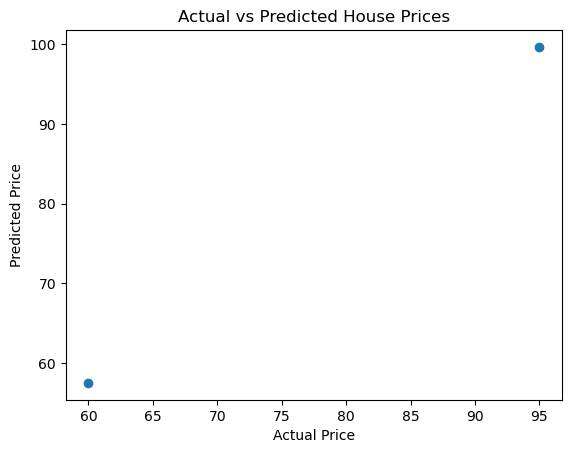

In [9]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [10]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])

print(coeff_df)


          Coefficient
Rooms       -2.142857
Distance     1.071429
Bathroom    -1.428571
Car         -1.428571
Landsize     0.214286
